# iprPy phonon calculation

In [19]:
# Standard library imports
import datetime

# http://www.numpy.org/
import numpy as np

# https://ipython.org/
from IPython.display import display, Code, Markdown, Pretty, Image

import matplotlib.pyplot as plt

# https://github.com/usnistgov/atomman 
import atomman as am
import atomman.unitconvert as uc

# https://github.com/usnistgov/iprPy
import iprPy

print('Notebook last executed on', datetime.date.today(), 'using iprPy version', iprPy.__version__)

Notebook last executed on 2026-06-25 using iprPy version 0.12.a


## 1. Load calculation and view description

### 1.1. Load the calculation

In [2]:
# Load the calculation being demoed
calculation = iprPy.load_calculation('phonon')

### 1.2. Display calculation description and theory

In [3]:
# Display main docs and theory
display(Markdown(calculation.maindoc))
display(Markdown(calculation.theorydoc))

# phonon calculation style

**Lucas M. Hale**, [lucas.hale@nist.gov](mailto:lucas.hale@nist.gov?Subject=ipr-demo), *Materials Science and Engineering Division, NIST*.

## Introduction

The phonon calculation style applies small atomic displacements to a unit cell system and evaluates the forces on the atoms to evaluate phonon-based properties.

### Version notes

- 2020-12-21: Script extended to include quasiharmonic calculations.
- v0.11.0: Notebook updated to reflect version 0.11.
- v0.12.0: Method updated to support the LAMMPS library interface.
  
### Additional dependencies

- [spglib](https://atztogo.github.io/spglib/python-spglib.html)
- [phonopy](https://atztogo.github.io/phonopy/)
- [seekpath](https://pypi.org/project/seekpath/)

### Disclaimers

- [NIST disclaimers](http://www.nist.gov/public_affairs/disclaimer.cfm)


## Method and Theory

Starting with an initial system, [spglib](https://atztogo.github.io/spglib/python-spglib.html) is used to identify the associated primitive unit cell.  The primitive cell is passed to [phonopy](https://atztogo.github.io/phonopy/), which constructs super cell systems with small atomic displacements.  A LAMMPS calculation is performed on the displaced systems to evaluate the atomic forces on each atom without relaxing.  The measured atomic forces are then passed back to phonopy, which computes force constants for the system.  Plots are then created for the band structure, density of states, and other thermal properties.

See [phonopy](https://atztogo.github.io/phonopy/) documentation for more details about the package and the associated theory.


## 2. Display the underlying code

This section displays the underlying code used when calculation.calc() is called in Section 4. It is provided here allowing any users to see and understand how the calculation works.

Feel free to modify and test the functions for yourself!  You can do this by
1. Copy the Python code displayed here into a "Code" cell and run it.
2. In Section 2.2, set "savefiles = True" and run the cell to save any supporting non-python files to the working directory.
3. In Section 4, call the primary calculation function directly rather than using calculation.calc().

### 2.1. Show code and supporting file names and content

In [4]:
# Display calculation code and supporting files
for filename, contents in calculation.files.items():
    display(Markdown(f'## Contents of file "{filename}"'))
    if filename[-3:] == '.py':
        display(Code(contents, language='python'))
    else:
        display(Pretty(contents))

## Contents of file "calc_phonon.py"

# Python script created by Lucas Hale

# Standard Python libraries
from pathlib import Path
from typing import Optional, Union

# http://www.numpy.org/
import numpy as np

import pandas as pd

# https://matplotlib.org/
import matplotlib.pyplot as plt

# https://atztogo.github.io/phonopy/phonopy-module.html
try:
    import phonopy
except ImportError:
    raise ImportError("The package, phonopy, is not installed by default. Please install with pip or conda.")

from DataModelDict import DataModelDict as DM

# https://github.com/usnistgov/atomman
import atomman as am
import atomman.unitconvert as uc
from atomman.typing import lammpspotential
from atomman.lammps import LAMMPS, LAMMPSobj

def phonon_quasiharmonic(lammps_command: Union[str, LAMMPSobj],
                         ucell: am.System,
                         potential: lammpspotential,
                         mpi_command: Optional[str] = None,
                         a_mult: int = 2,
                         b_mult: int = 2,
                         c_mult: int = 2,
                         distance: float = 0.01,
                         symprec: float = 1e-5,
                         strainrange: float = 0.01,
                         numstrains: int = 5,
                         usefiles: bool = False) -> dict:
    """
    Function that performs phonon and quasiharmonic approximation calculations
    using phonopy and LAMMPS.

    Parameters
    ----------
    lammps_command : str, LAMMPSEXE or LAMMPSLIB
        LAMMPS executable command, LAMMPS library name, or an atomman LAMMPS
        interface object.
    ucell : atomman.System
        The unit cell system to perform the calculation on.
    potential : PotentialLAMMPS or PotentialLAMMPSKIM
        The LAMMPS implemented potential to use.
    mpi_command : str, optional
        The MPI command for running LAMMPS in parallel.  If not given, LAMMPS
        will run serially.
    a_mult : int, optional
        The a size multiplier to use on ucell before running the phonon
        calculation.  Must be an int and not a tuple.  Default value is 2.
    b_mult : int, optional
        The b size multiplier to use on ucell before running the phonon
        calculation.  Must be an int and not a tuple.  Default value is 2.
    c_mult : int, optional
        The c size multiplier to use on ucell before running the phonon
        calculation.  Must be an int and not a tuple.  Default value is 2.
    distance : float, optional
        The atomic displacement distance used for computing the phonons.
        Default value is 0.01.
    symprec : float, optional
        Absolute length tolerance to use in identifying symmetry of atomic
        sites and system boundaries. Default value is 1e-5.
    strainrange : float, optional
        The range of strains to apply to the unit cell to use with the
        quasiharmonic calculations.  Default value is 0.01.
    numstrains : int, optional
        The number of strains to use for the quasiharmonic calculations.
        Must be an odd integer.  If 1, then the quasiharmonic calculations
        will not be performed.  Default value is 5.
    """
    # Create a LAMMPS object if needed
    lmp = LAMMPS(lammps_command, mpi_command=mpi_command, potential=potential)

    # Convert ucell to a primitive cell
    ucell = ucell.dump('primitive_cell', symprec=symprec)

    # Get unstrained box vectors
    vects = ucell.box.vects

    # Generate the range of strains
    if numstrains == 1:
        zerostrain = phononcalc(lmp, ucell,
                                a_mult=a_mult, b_mult=b_mult, c_mult=c_mult,
                                distance=distance, symprec=symprec, usefiles=usefiles)
        phonons = [zerostrain['phonon']]
        qha = None

    elif numstrains % 2 == 0 or numstrains < 5:
        raise ValueError('Invalid number of strains: must be odd and 1 or >= 5')
    else:
        strains = np.linspace(-strainrange, strainrange, numstrains)
        istrains = np.linspace(-(numstr

### 2.2. Optional: Save supporting files

Set "savefiles = True" to save files locally.  

Note that the code above should be using atomman.tools.read_calc_file() to read the files, which will read any local files with matching names if they exist or read the packaged version if the local files do not exist. This means that if you save the files locally, you can modify them and see how it affects the calculation!

In [5]:
savefiles = False

if savefiles:
    for filename, contents in calculation.files.items():
        if filename[-3:] != '.py':
            with open(filename, 'w') as f:
                f.write(contents)

## 3. Specify input parameters

### 3.1. System-specific paths

- __lammps_command__ is the LAMMPS command to use (required).
- __mpi_command__ MPI command for running LAMMPS in parallel. A value of None will run simulations serially.

In [6]:
lammps_command = 'lmp_serial'
mpi_command = None
#mpi_command = 'mpiexec -localonly 4'

# Optional: check that LAMMPS works and show its version 
print(f'LAMMPS version = {am.lammps.checkversion(lammps_command)["version"]}')

LAMMPS version = 3 Mar 2020


### 3.2. Interatomic potential

- __potential_name__ gives the name of a potential_LAMMPS record to find and download from the iprPy library.  
- __potential__ is a potential_LAMMPS or potential_LAMMPS_KIM record object (required).

See documentation for the [potentials package](https://github.com/usnistgov/potentials/tree/master/doc) for more options on finding, loading and building potential objects (doc Notebook #s 0, 5.3, 5.4 and 7).

In [7]:
potential_name = '1999--Mishin-Y--Ni--LAMMPS--ipr1'

# Retrieve potential and parameter file(s)
potential = am.load_lammps_potential(id=potential_name, getfiles=True)

### 3.3. Initial unit cell system

- __ucell__ is an atomman.System representing a fundamental unit cell of the system (required).  Here, this is generated using the load parameters and symbols.

See documentation for the [atomman package](https://github.com/lmhale99/atomman/tree/master/doc/tutorial) for more options on building and loading atomic configurations (doc Notebook #s 1.1, 1.2, 1.3, 1.4 and 1.4.*)

In [8]:
# Create ucell by loading prototype record
ucell = am.load('crystal', potential=potential, family='A1--Cu--fcc')

print(ucell)

Multiple matching record retrieved from remote
#  family               symbols  alat    Ecoh    method  standing
 1 A1--Cu--fcc          Ni        3.5200 -4.4500 dynamic good
 2 A1--Cu--fcc          Ni        7.3760  0.0119 dynamic good


Please select one: 1


avect =  [ 3.520,  0.000,  0.000]
bvect =  [ 0.000,  3.520,  0.000]
cvect =  [ 0.000,  0.000,  3.520]
origin = [ 0.000,  0.000,  0.000]
natoms = 4
natypes = 1
symbols = ('Ni',)
pbc = [ True  True  True]
per-atom properties = ['atype', 'pos']
     id |   atype |  pos[0] |  pos[1] |  pos[2]
      0 |       1 |   0.000 |   0.000 |   0.000
      1 |       1 |   0.000 |   1.760 |   1.760
      2 |       1 |   1.760 |   0.000 |   1.760
      3 |       1 |   1.760 |   1.760 |   0.000


### 3.4. System modifications

- __sizemults__ list of three integers specifying how many times the ucell vectors of $a$, $b$ and $c$ are replicated in creating system.
- __system__ is an atomman.System to perform the scan on (required). 

In [9]:
sizemults = [2, 2, 2]

# Generate system by supersizing ucell
system = ucell.supersize(*sizemults)
print('# of atoms in system =', system.natoms)

# of atoms in system = 32


### 3.5. Calculation-specific parameters

- __displacementdistance__ is the displacement distance scalar to use when applying random displacements to the atoms to compute the force constants.   
- __symmetryprecision__ is the absolute precision tolerance to use in determining crystal symmetry elements for identifying the primitive unit cell.   
- __strainrange__ is the size of the largest strain used for the quasiharmonic calculations.
- __numstrains__ is the number of strain states to use for the quasiharmonic calculation.  Needs to be odd and either 1 or greater than or equal to 5.  If set to 1, then the quasiharmonic calculations will not be performed.

In [10]:
displacementdistance = uc.set_in_units(0.01, 'angstrom')
symmetryprecision = 1e-5
strainrange = 0.01
numstrains = 5

## 4. Run calculation and view results

### 4.1. Run calculation

All primary calculation method functions take a series of inputs and return a dictionary of outputs.

In [11]:
# What is calculation.calc an alias of?
calculation.calc.__module__

'iprPy.calculation.phonon.calc_phonon'

In [12]:
results_dict = calculation.calc(lammps_command, ucell, potential,
                                mpi_command = mpi_command,
                                a_mult = sizemults[0],
                                b_mult = sizemults[1],
                                c_mult = sizemults[2],
                                distance = displacementdistance,
                                symprec = symmetryprecision,
                                strainrange = strainrange,
                                numstrains = numstrains)
print(results_dict.keys())

dict_keys(['phonon_objects', 'qha_object', 'band_structure', 'density_of_states', 'thermal_properties', 'qha_eos', 'volume_scan', 'E0', 'B0', 'B0prime', 'V0'])


### 4.2. Report results

The calculation both returns results_dict containing phonon information and generates files. 

#### 4.2.1. Phonon properties

In results_dict:

- __phonon_objects__ is a list containing all of the Phonopy objects at all of the strains evaluated.
- __band_structure__ contains the evaluated band structure points for the zero strain structure.
- __density_of_states__ contains the evaluated density of states (both total and projected) for the zero strain structure.
- __thermal_properties__ contains the temperature-dependent Helmholtz free energy, entropy, and constant volume heat capacity.

Generated files:

- __band.png__ plots the band structure for the zero strain structure.
- __phonopy_params.yaml__ is the YAML-formatted Phonopy data that can be read back in to generate a Phonopy object later.  

#### 4.2.2. Quasiharmonic properties

These are only generated if numstrains is greater than 1.

In results_dict:

- __qha_object__ is the PhonopyQHA object.
- __volume_scan__ contains the energy versus volume evaluations taken from the different strain states.
- __E0, B0, B0prime, V0__ are the energy, Bulk modulus, B' modulus, and volume associated with the interpolated equilibrium state from the volume scan.
- __thermal_properties__ is expanded to also include the temperature-dependent volume, thermal expansion, Gibbs free energy, bulk modulus, constant pressure heat capacity, and Grüneisen parameter.

Generated files:

- __bulk_modulus.png__ plots the volume scan data as it is used to estimate the bulk modulus.  This plot provides a quick visual means of telling if the quasiharmonic analysis is likely good for the strains explored. 
- __helmholtz.png__ plots the helmholtz free energy versus volume.  
- __phonopy_params_\*.yaml__ are the YAML-formatted Phonopy data for the non-zero strains that can be read back in to generate Phonopy objects later. 

Band structure plot and values

keys of "band_structure": dict_keys(['qpoints', 'distances', 'frequencies', 'eigenvectors', 'group_velocities'])


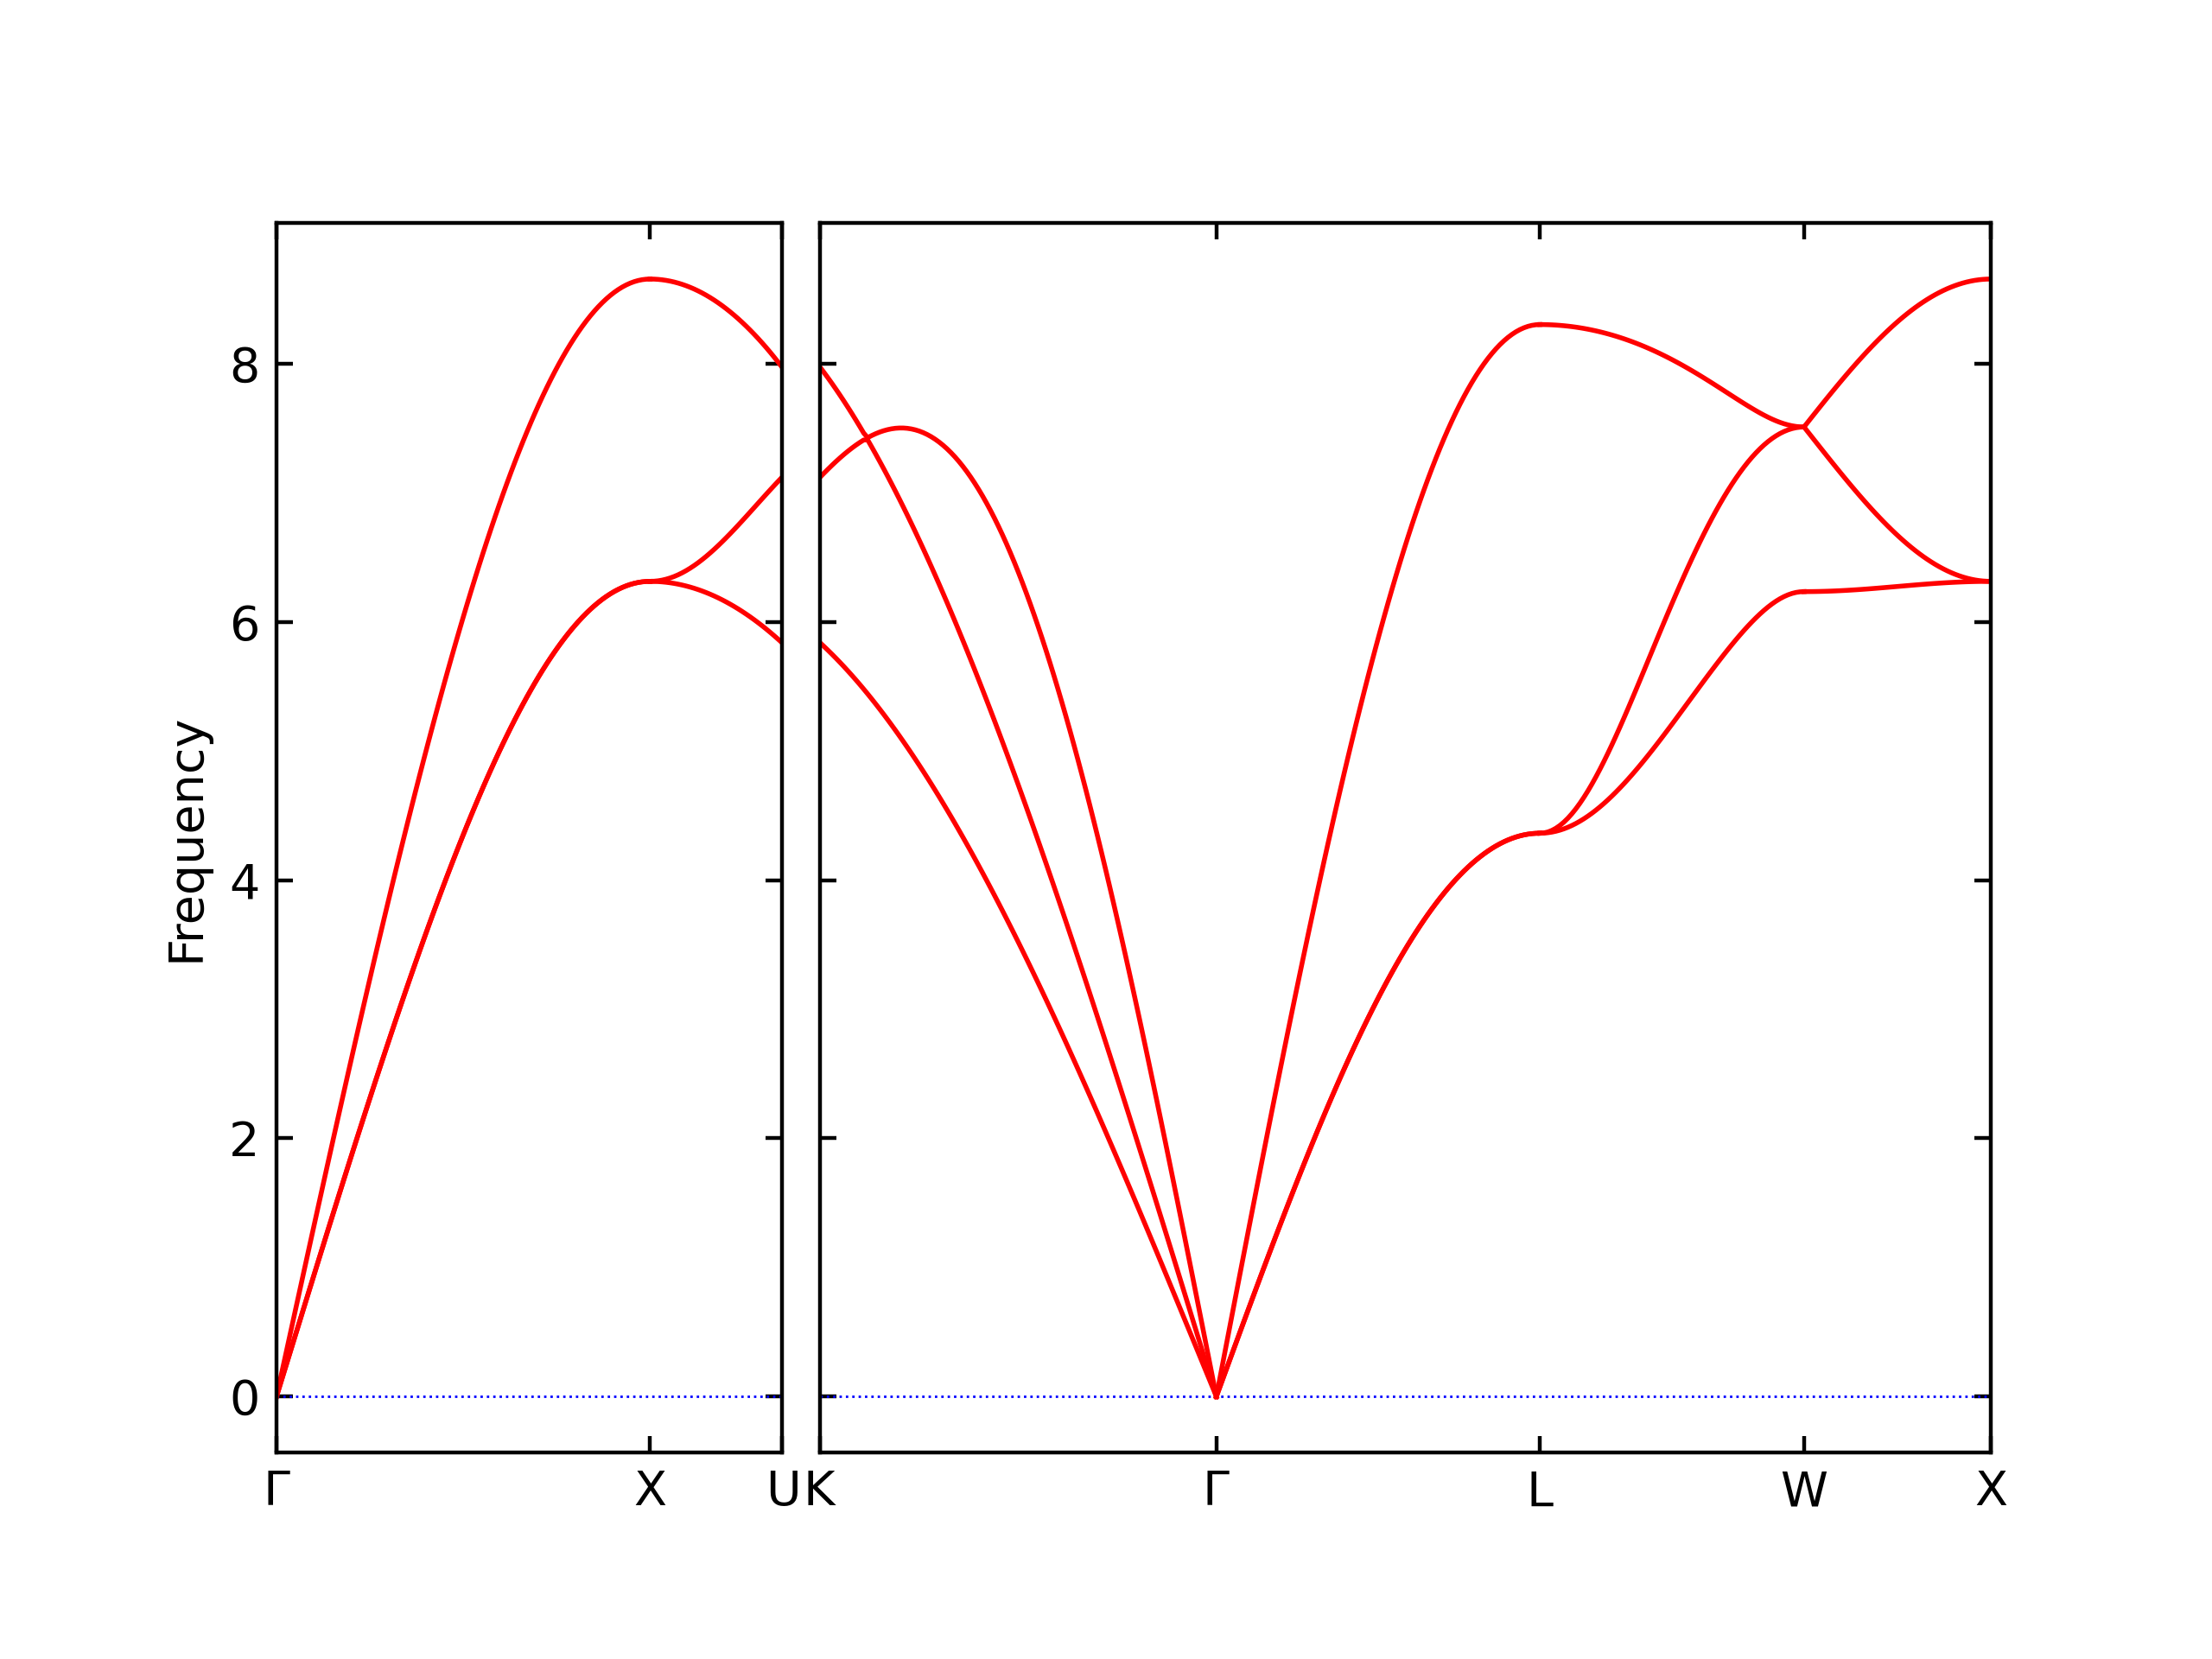

In [15]:
print('keys of "band_structure":', results_dict['band_structure'].keys())
Image("band.png", width=600)

Volume versus energy scan plot and values

keys of "volume_scan": dict_keys(['volume', 'strain', 'energy'])
E0 = -4.450015291313849 eV
B0 = 187.29675909231602 GPa
B0`= 165.99239701360304 GPa
V0 = 10.903240148091013 Å^3


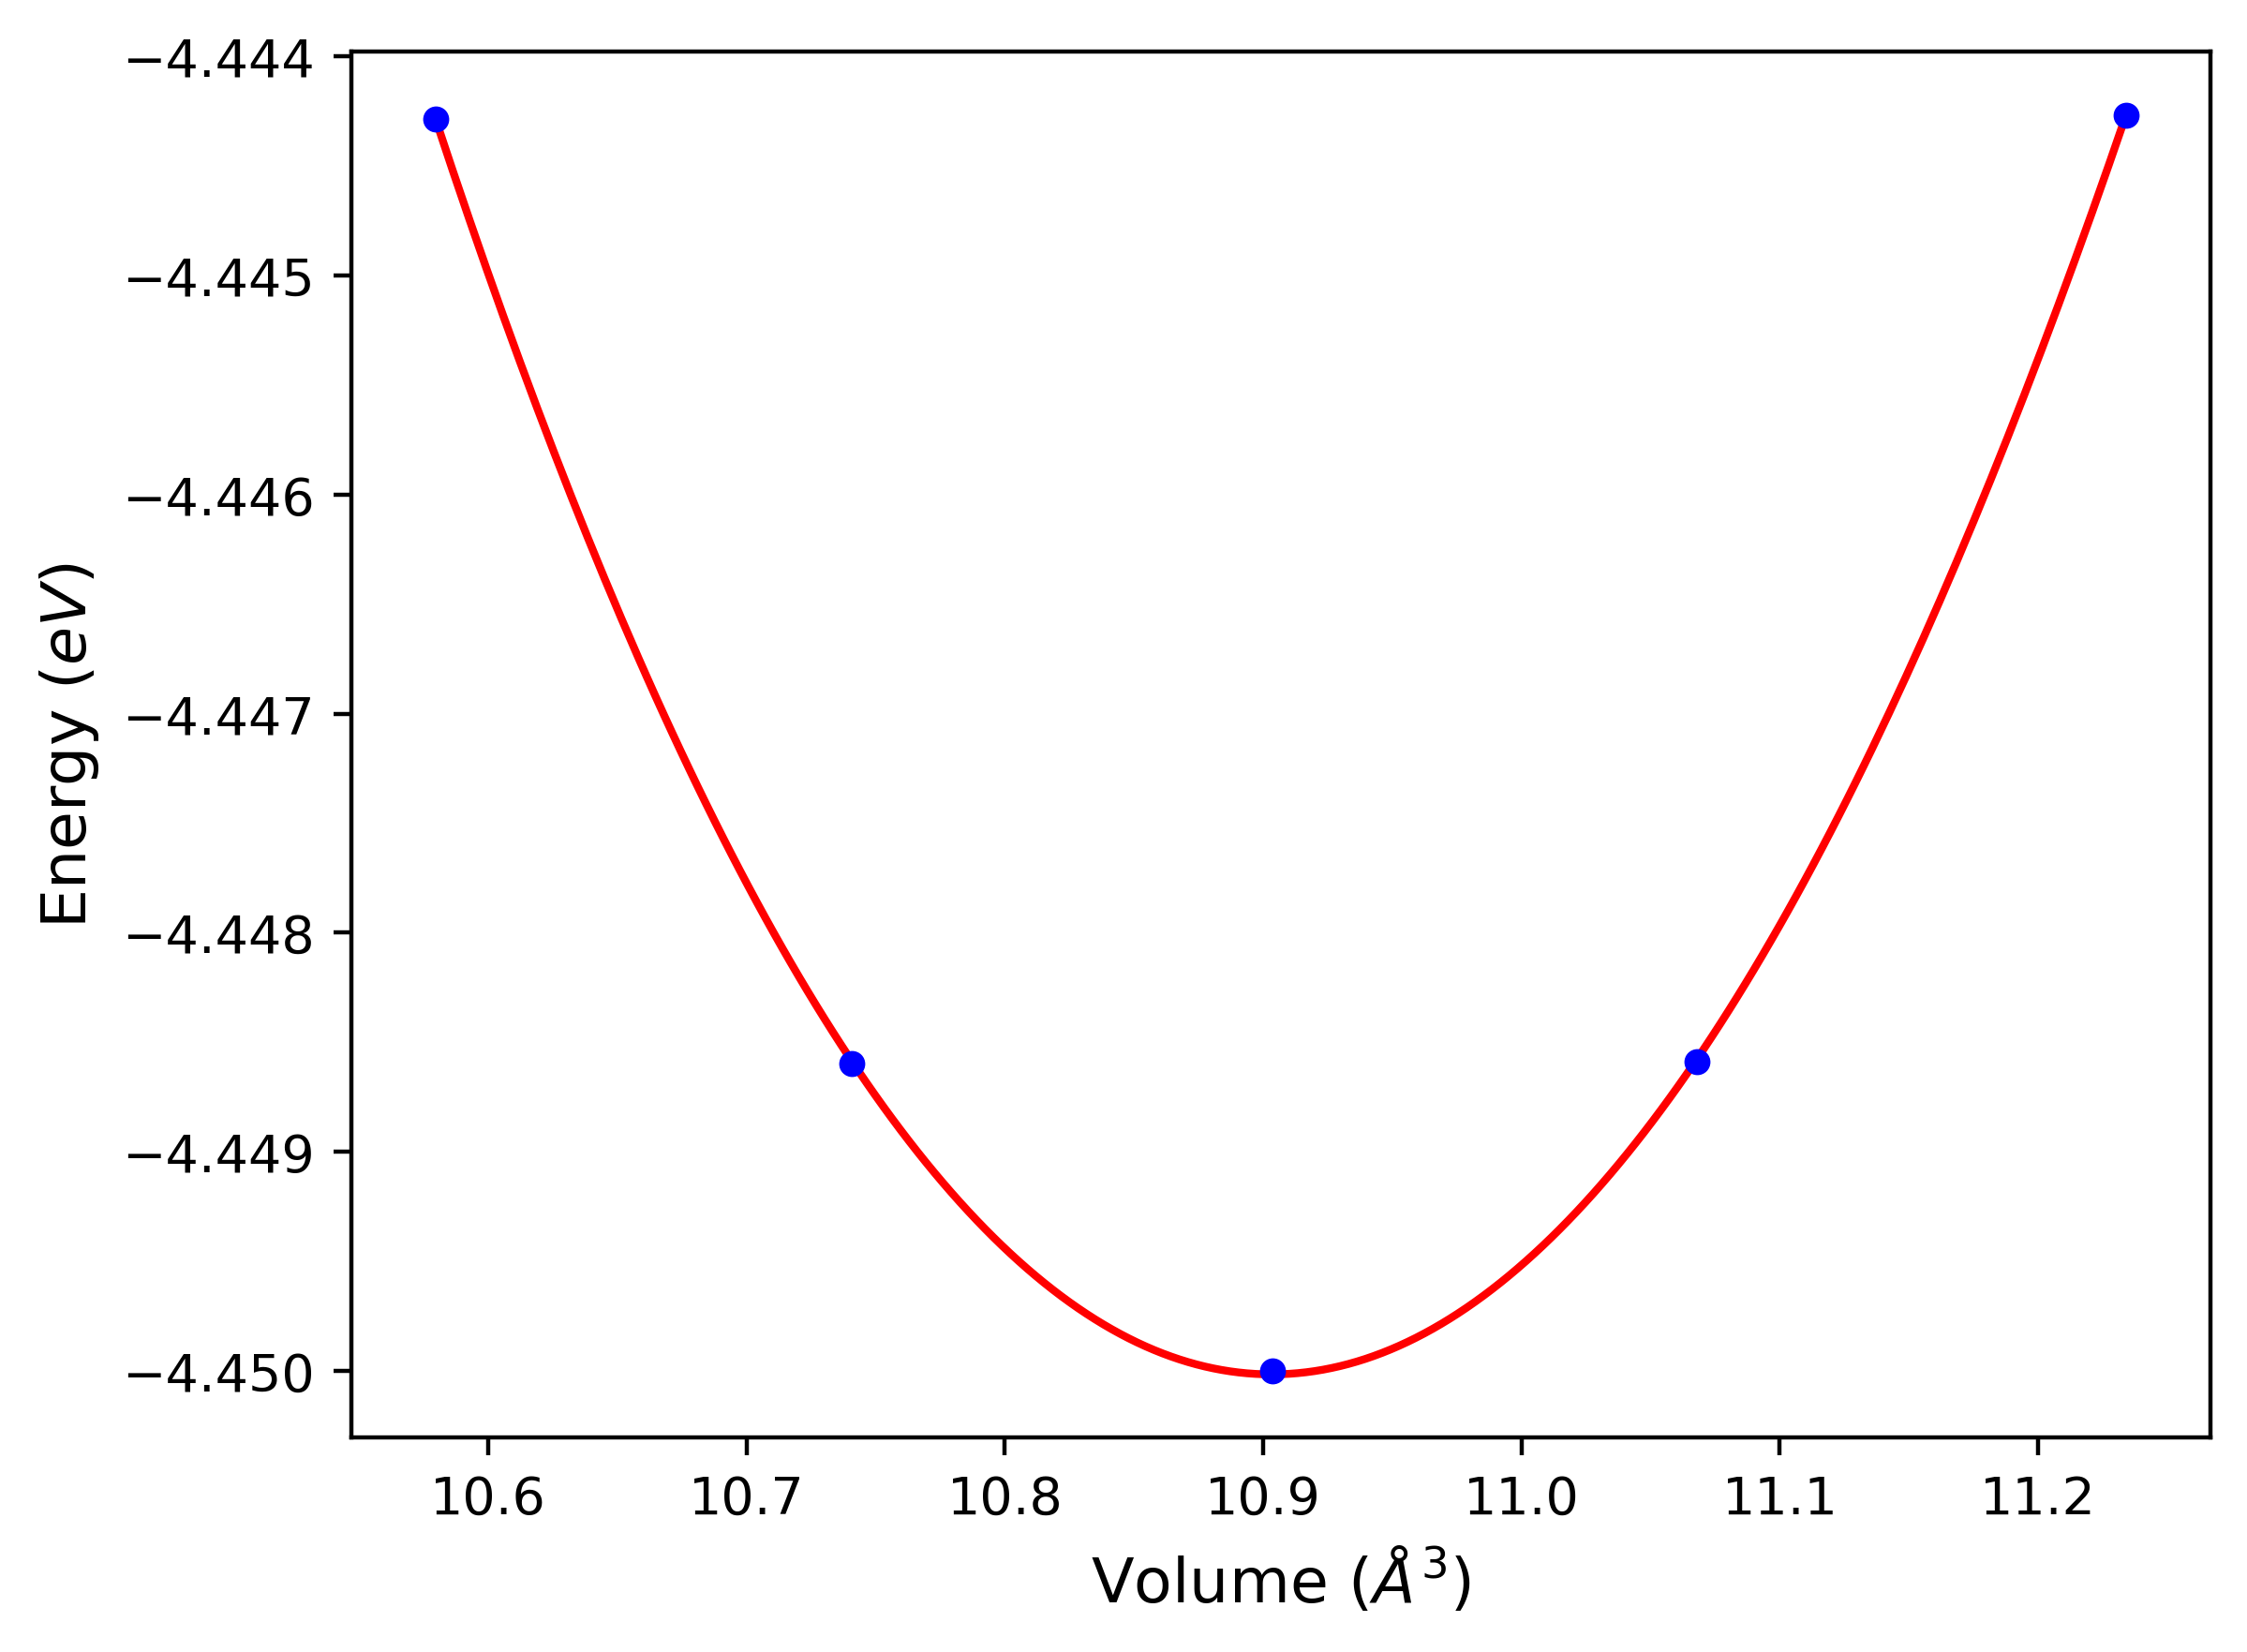

In [16]:
print('keys of "volume_scan":',results_dict['volume_scan'].keys())
print('E0 =', uc.get_in_units(results_dict['E0'], 'eV'), 'eV')
print('B0 =', uc.get_in_units(results_dict['B0'], 'GPa'), 'GPa')
print('B0`=', uc.get_in_units(results_dict['B0prime'], 'GPa'), 'GPa')
print('V0 =', uc.get_in_units(results_dict['V0'], 'Å^3'), 'Å^3')

Image("bulk_modulus.png", width=600)

Helmholtz free energy versus volume plot

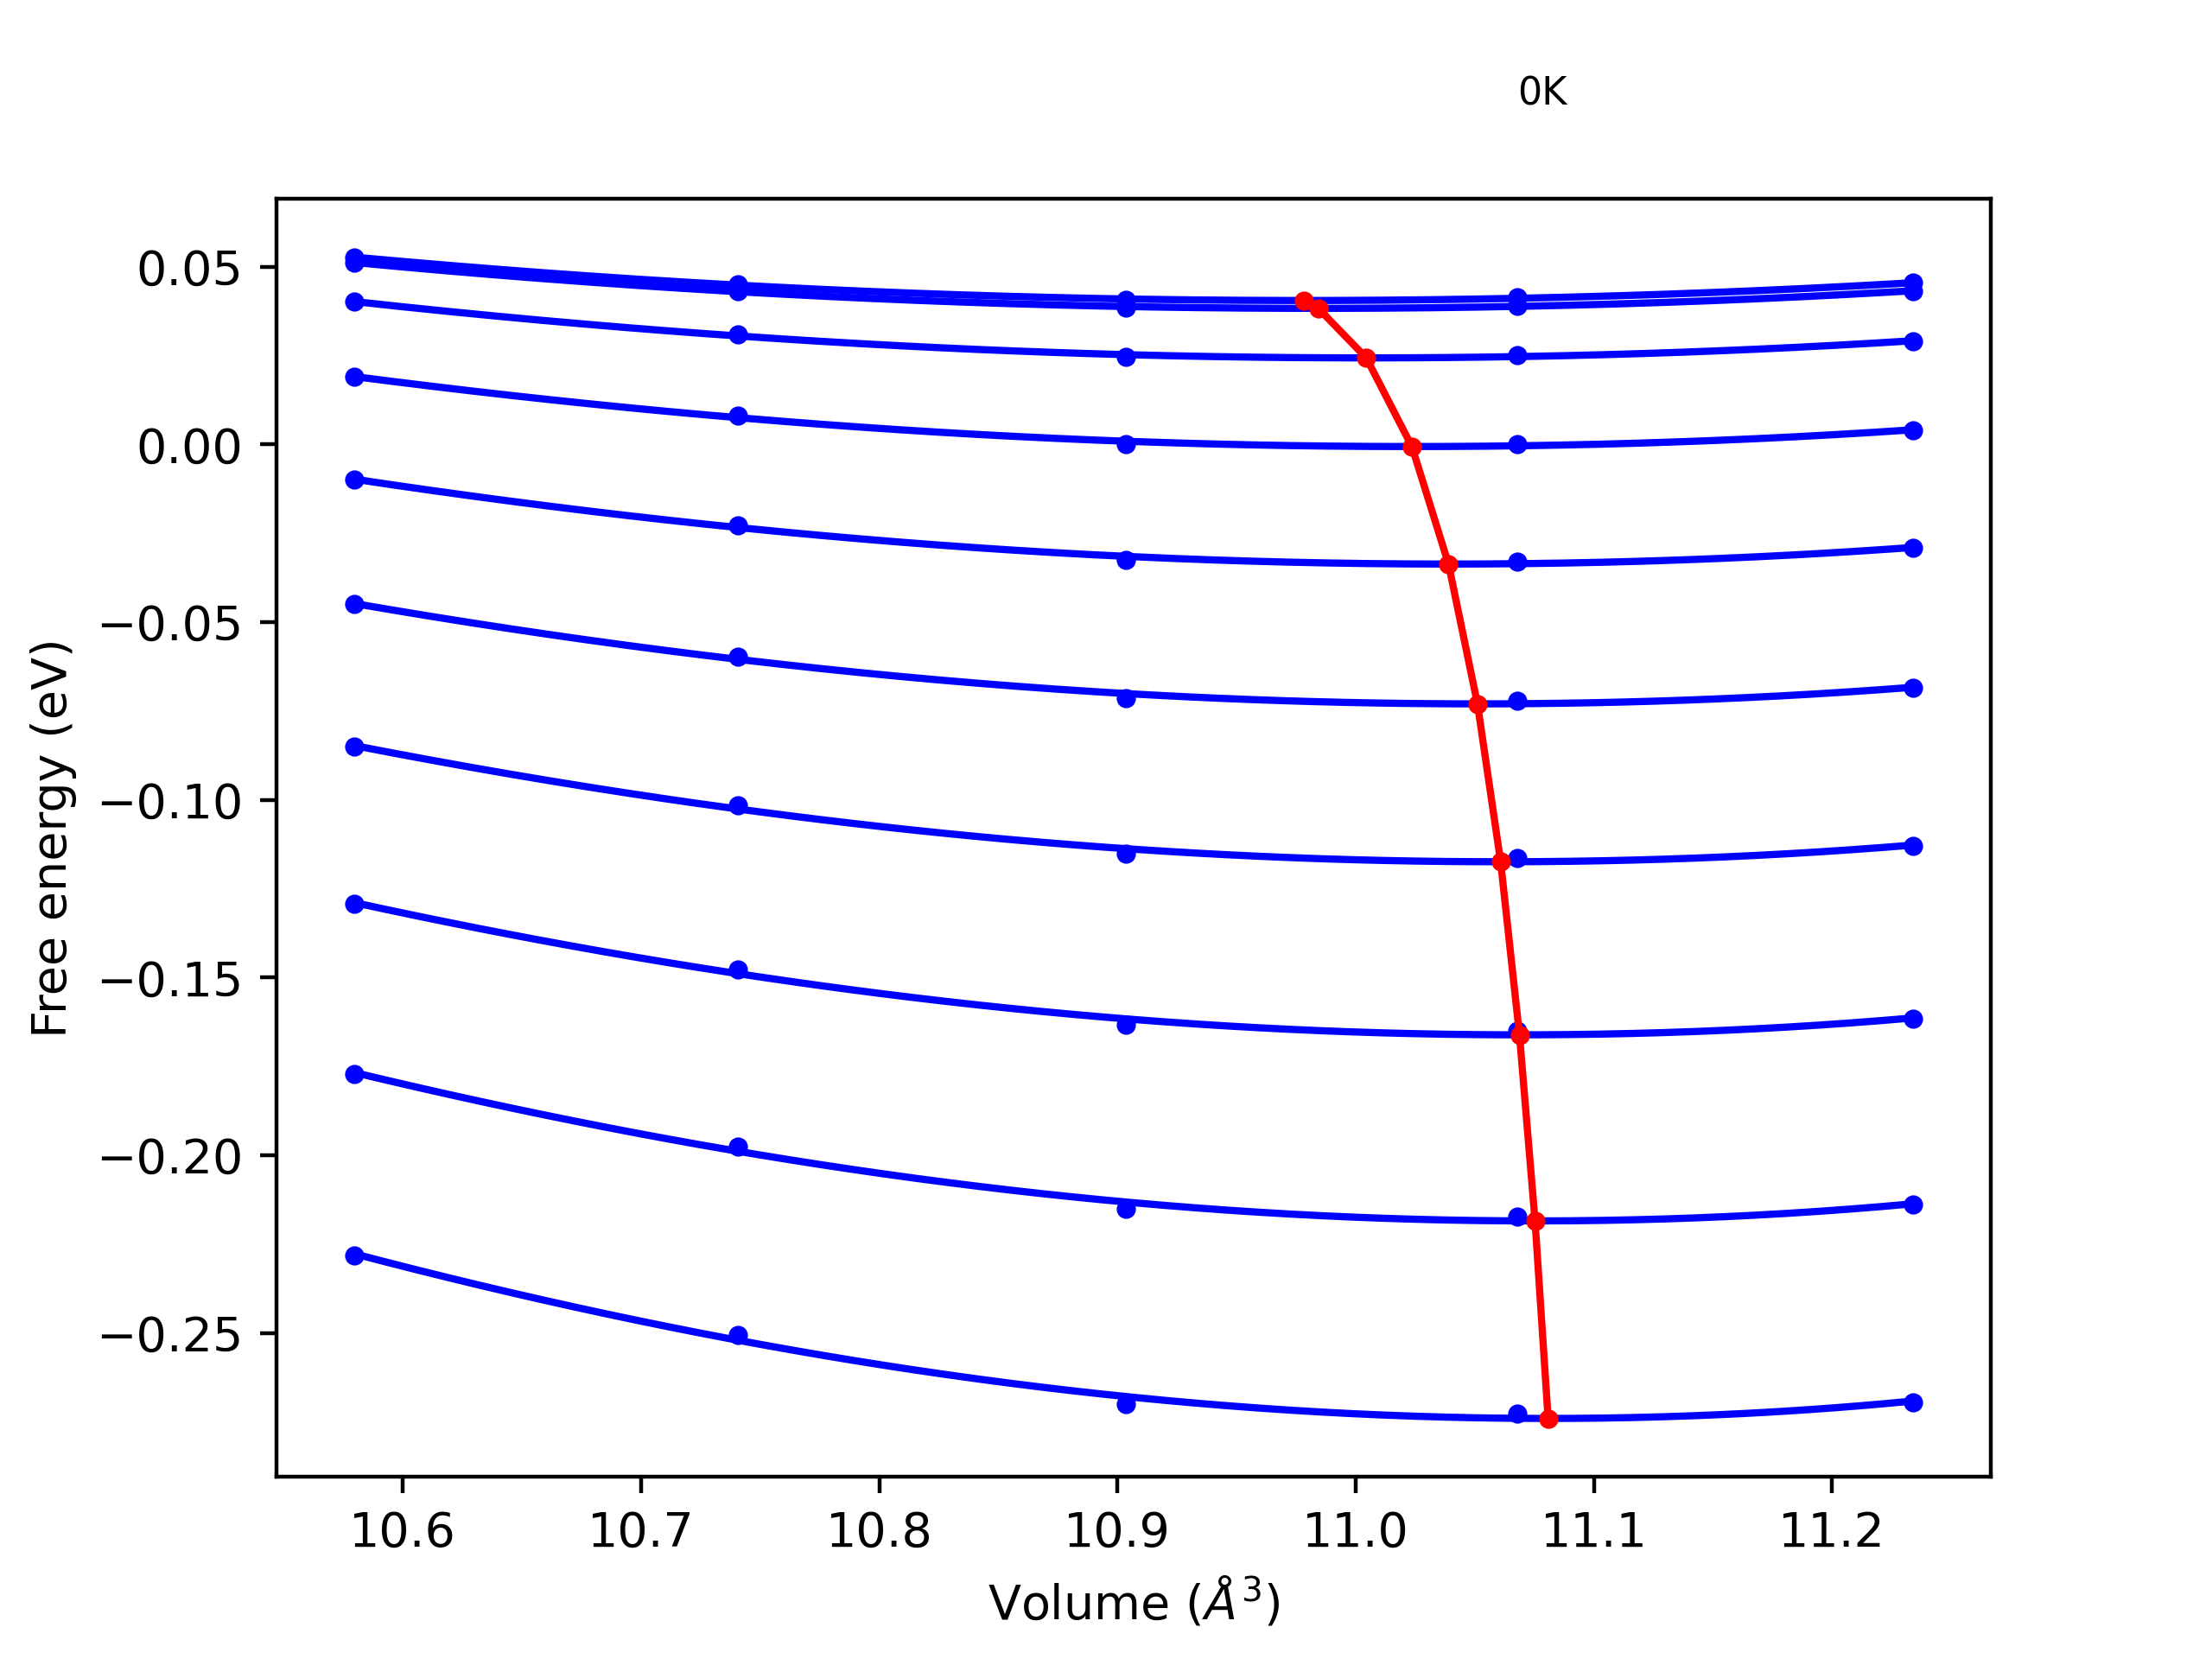

In [17]:
Image("helmholtz_volume.png", width=600)

Density of states

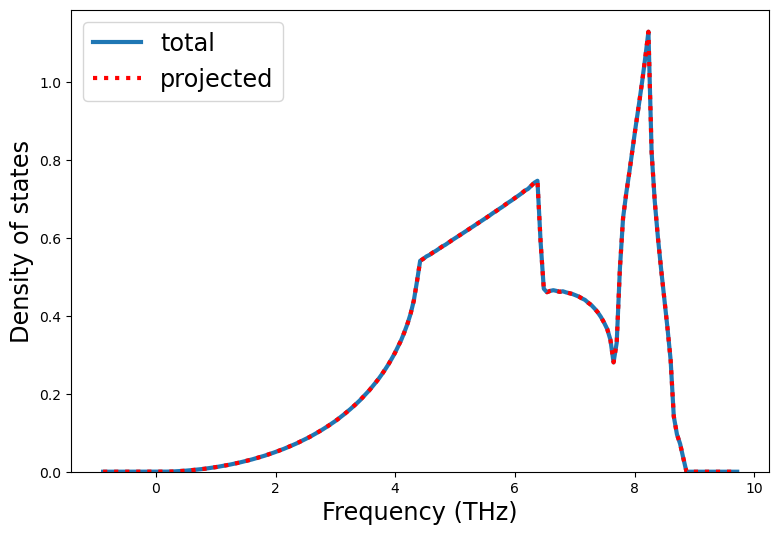

In [20]:
dos = results_dict['density_of_states']

fig = plt.figure(figsize=(9,6))

frequency = uc.get_in_units(dos['frequency'], 'THz')
plt.plot(frequency, dos['total_dos'], '-', lw=3, label='total')
for projected in dos['projected_dos']:
    plt.plot(frequency, projected, 'r:', lw=3, label='projected')
plt.xlabel('Frequency (THz)', size='xx-large')
plt.ylabel('Density of states', size='xx-large')
plt.legend(loc=2, fontsize='xx-large')
plt.ylim(0.0, None)
plt.show()

Thermal properties - pull out temperature

In [21]:
results_dict['thermal_properties'].keys()

thermal = results_dict['thermal_properties']
temperature = thermal['temperature']

Helmholtz and Gibbs free energies versus temperature

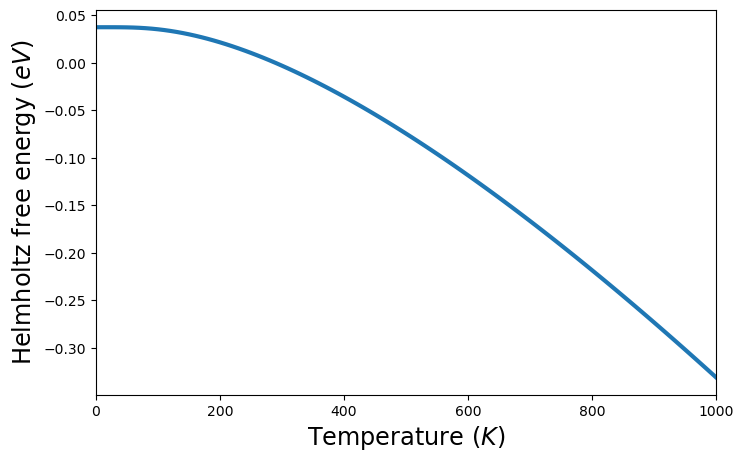

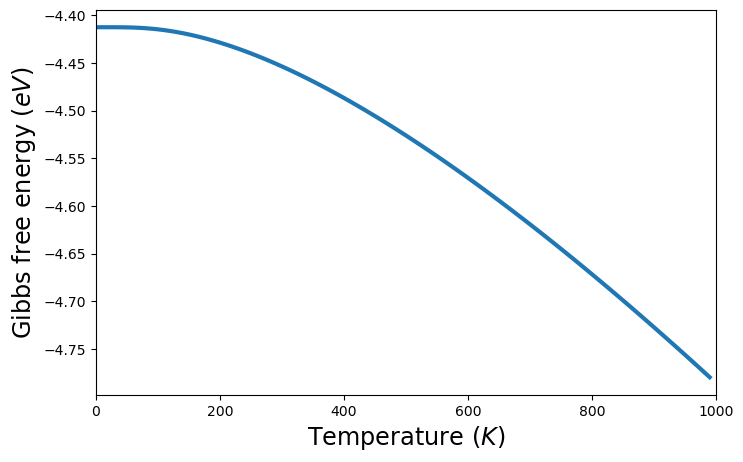

In [22]:
energy_unit = 'eV'
#energy_unit = 'kJ/mol'

fig = plt.figure(figsize=(8,5))
helmholtz = uc.get_in_units(thermal['Helmholtz'], energy_unit)
plt.plot(temperature, helmholtz, '-', lw=3)
plt.xlabel('Temperature ($K$)', size='xx-large')
plt.xlim(0, 1000)
plt.ylabel(f'Helmholtz free energy (${energy_unit}$)', size='xx-large')
plt.show()

fig = plt.figure(figsize=(8,5))
gibbs = uc.get_in_units(thermal['Gibbs'], energy_unit)
plt.plot(temperature, gibbs, '-', lw=3)
plt.xlabel('Temperature ($K$)', size='xx-large')
plt.xlim(0, 1000)
plt.ylabel(f'Gibbs free energy (${energy_unit}$)', size='xx-large')
plt.show()

Entropy and heat capacity versus temperature

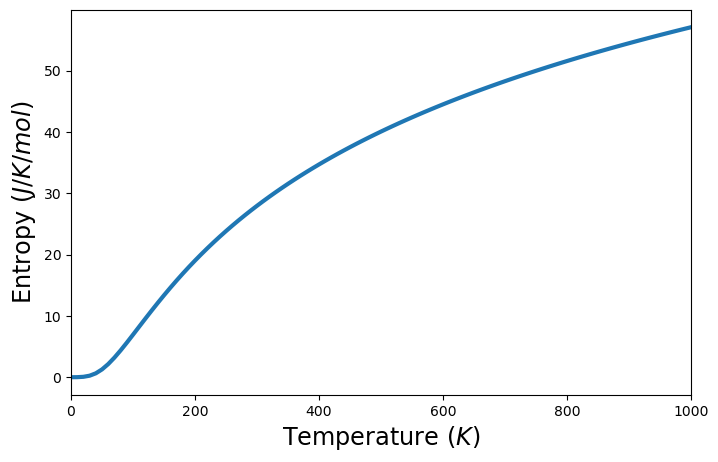

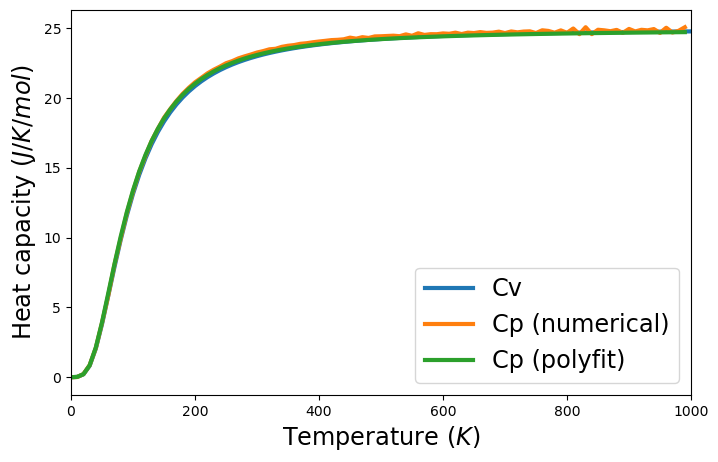

In [23]:
#entropy_unit = 'eV/K'
entropy_unit = 'J/K/mol'

fig = plt.figure(figsize=(8,5))
entropy = uc.get_in_units(thermal['entropy'], entropy_unit)
plt.plot(temperature, entropy, '-', lw=3)
plt.xlabel('Temperature ($K$)', size='xx-large')
plt.xlim(0, 1000)
plt.ylabel(f'Entropy (${entropy_unit}$)', size='xx-large')
plt.show()

fig = plt.figure(figsize=(8,5))
heat_capacity_v = uc.get_in_units(thermal['heat_capacity_v'], entropy_unit)
heat_capacity_p_numerical = uc.get_in_units(thermal['heat_capacity_p_numerical'], entropy_unit)
heat_capacity_p_polyfit = uc.get_in_units(thermal['heat_capacity_p_polyfit'], entropy_unit)

plt.plot(temperature, heat_capacity_v, '-', lw=3, label='Cv')
plt.plot(temperature, heat_capacity_p_numerical, '-', lw=3, label='Cp (numerical)')
plt.plot(temperature, heat_capacity_p_polyfit, '-', lw=3, label='Cp (polyfit)')
plt.xlabel('Temperature ($K$)', size='xx-large')
plt.xlim(0, 1000)
plt.ylabel(f'Heat capacity (${entropy_unit}$)', size='xx-large')
plt.legend(loc=4, fontsize='xx-large')
plt.show()

Volume versus temperature

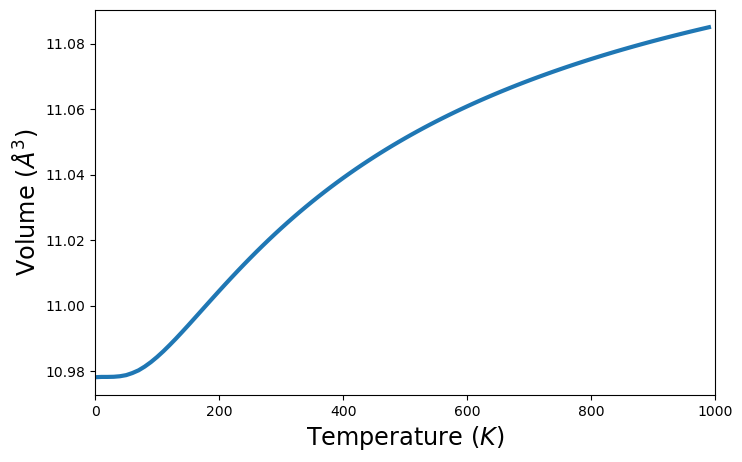

In [24]:
volume_unit = 'Å^3'
#volume_unit = 'nm^3'

fig = plt.figure(figsize=(8,5))
volume = uc.get_in_units(thermal['volume'], volume_unit)
plt.plot(temperature, volume, '-', lw=3)
plt.xlabel('Temperature ($K$)', size='xx-large')
plt.xlim(0, 1000)
plt.ylabel(f'Volume (${volume_unit}$)', size='xx-large')
plt.show()

Thermal expansion versus temperature

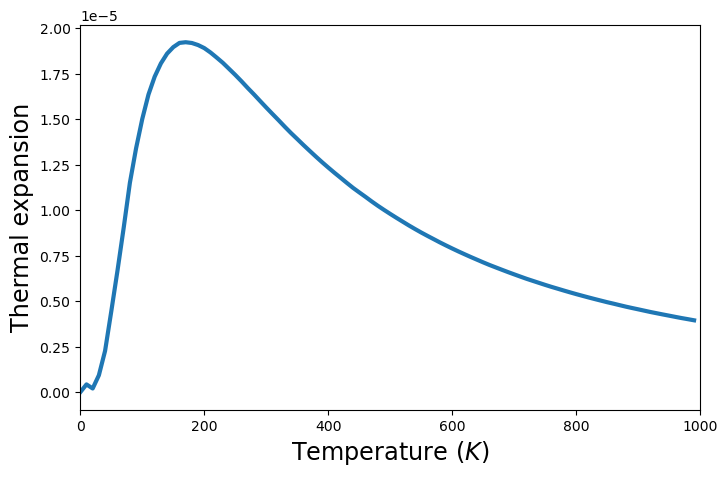

In [25]:
fig = plt.figure(figsize=(8,5))
expansion = thermal['thermal_expansion']
plt.plot(temperature, expansion, '-', lw=3)
plt.xlabel('Temperature ($K$)', size='xx-large')
plt.xlim(0, 1000)
plt.ylabel(f'Thermal expansion', size='xx-large')
plt.show()

Grüneisen parameter versus temperature

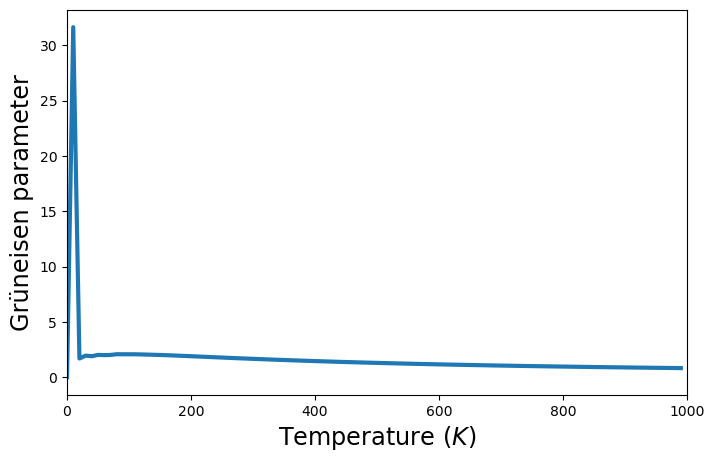

In [26]:
fig = plt.figure(figsize=(8,5))
gruneisen = thermal['gruneisen']
plt.plot(temperature, gruneisen, '-', lw=3)
plt.xlabel('Temperature ($K$)', size='xx-large')
plt.xlim(0, 1000)
plt.ylabel(f'Grüneisen parameter', size='xx-large')
plt.show()

### 4.3. Optional: Clean calculation files

The calculation may generate output files when it runs.  Calling calculation.clean_files() will delete any generated files to keep the workspace clean.

In [27]:
calculation.clean_files()